In [7]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [35]:
with open("data.pickle", "rb") as f:
    data = pickle.load(f)

states = [
    "x",
    "y",
    "z",
    "mouse_can_report",
    "ITI",
    "spawner_green_on_left",
    "mouse_report_correct",
    "mouseInLeft_box",
    "mouseInRight_box",
    "speed",
    "photodiode_sync_state",
    "photodiode_change_value",
    "start_box_delay",
]
data_df = pd.DataFrame(
    data=data["action"].reshape(
        data["action"].shape[0],
        data["action"].shape[2],
    ),
    columns=["action_x", "action_y", "action_head_angle", "action_photodiode"],
)
data_df["episode"] = data["episode"]
data_df["step"] = data["step"]
data_df[states] = data["state"]
data_df["terminal"] = data["terminal"]
data_df["reward"] = data["reward"]

In [36]:
data_df['episode'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])

In [37]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Table(
            header=dict(values=list(data_df.columns)),
            cells=dict(values=[data_df[col] for col in data_df.columns]),
        )
    ]
)
fig.show()

In [48]:
starts = (data_df.groupby("episode").first()["step"]).values
starts

array([   1,  328,  444,  800,  868,  951, 1043, 1155, 1256, 1374, 1470,
       1735, 1913])

In [47]:
ends = (data_df[data_df.ITI == 1].groupby("episode").first()["step"] - 1).values
ends

array([ 300,  406,  486,  837,  918, 1014, 1119, 1224, 1338, 1433, 1635,
       1838])

In [38]:
episodes_df = (
    data_df[data_df.ITI == 1].set_index(["episode", "step"]).copy(deep=True)
)
fig = go.Figure(
    data=[
        go.Table(
            header=dict(values=list(episodes_df.columns)),
            cells=dict(values=[episodes_df[col] for col in episodes_df.columns]),
        )
    ]
)
fig.show()

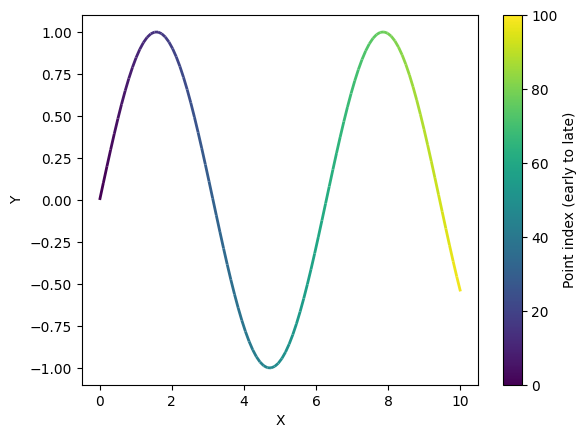

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

# Sample trajectory data
x = np.linspace(0, 10, 100)  # x coordinates
y = np.sin(x)  # y coordinates
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a color map (viridis)
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(0, len(x))

# Create the line segments with gradient coloring
lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(np.arange(len(x)))  # Set the color values based on the order of points
lc.set_linewidth(2)

# Plot
fig, ax = plt.subplots()
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("X")
ax.set_ylabel("Y")

# Colorbar to show the mapping
plt.colorbar(lc, ax=ax, label="Point index (early to late)")

plt.show()